# 11 発展課題（自作） 解答 — 能動交換
対象: [`notebooks/11_active_exchange.ipynb`](../notebooks/11_active_exchange.ipynb)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, matplotlib.pyplot as plt
from ecell4 import run_simulation
from ecell4_base.core import NetworkModel, ReactionRule, Species
H,M,S,MH,SH = (Species(x) for x in ['H','m','s','mH','sH'])
KON=0.1; SP=['H','m','s','mH','sH']
def R(a,b,k): return ReactionRule(a,b,k)
def build(k_ex, k_off=0.01):
    mdl=NetworkModel()
    for r in [R([M,H],[MH],KON),R([MH],[M,H],k_off),R([S,H],[SH],KON),R([SH],[S,H],k_off)]:
        mdl.add_reaction_rule(r)
    if k_ex>0:
        mdl.add_reaction_rule(R([MH,S],[SH,M],k_ex)); mdl.add_reaction_rule(R([SH,M],[MH,S],k_ex))
    return mdl
def traj(k_ex,k_off=0.01,t=60.,ndiv=600):
    return run_simulation(t,y0={'mH':10.,'m':90.,'s':20.},model=build(k_ex,k_off),solver='ode',ndiv=ndiv,species_list=SP).as_array()

## Q1. `k_ex` を 0→0.2 に振り、応答時間（sH が最終値の半分に達する時刻）

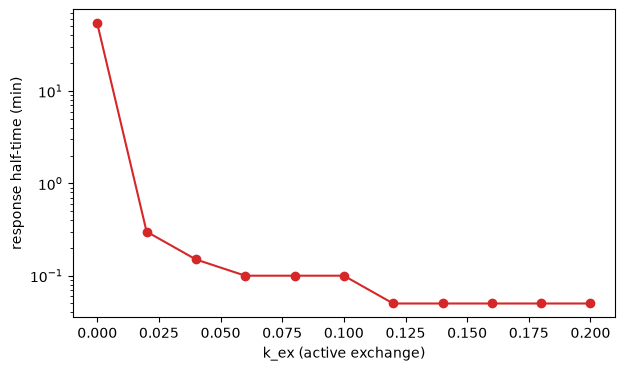

k_ex=0: 54 min | k_ex=0.05: 0.1 min | k_ex=0.2: 0.1 min


In [2]:
def half_time(k_ex):
    a=traj(k_ex,t=200.,ndiv=4000); sH=a[:,5]; fin=sH[-1]
    i=np.where(sH>=0.5*fin)[0][0]; return a[i,0]
kex=np.linspace(0.0,0.2,11); ht=[half_time(k) for k in kex]
fig,ax=plt.subplots(figsize=(7,4)); ax.plot(kex,ht,'o-',color='C3')
ax.set_xlabel('k_ex (active exchange)'); ax.set_ylabel('response half-time (min)'); ax.set_yscale('log'); plt.show()
print('k_ex=0:', f'{ht[0]:.0f} min |', 'k_ex=0.05:', f'{half_time(0.05):.1f} min |', 'k_ex=0.2:', f'{half_time(0.2):.1f} min')

**答**: `k_ex` を上げると応答半減時間が**急激に短縮**（passive の ~100 分オーダーから、わずかな k_ex で分オーダーへ）。ごく小さな能動交換でも、占有済み Hfq へのアクセスを劇的に速める。

## Q2. 結合をもっと強固に（`k_off`=0.001）すると passive と active の差は?

In [3]:
print(f"{'k_off':>7}{'passive sH(5min)':>18}{'active sH(5min)':>17}{'ratio':>8}")
for k_off in [0.01, 0.001]:
    p=traj(0.0,k_off)[50,5]; a=traj(0.05,k_off)[50,5]
    print(f'{k_off:7.3f}{p:18.3f}{a:17.2f}{a/max(p,1e-6):8.0f}')

  k_off  passive sH(5min)  active sH(5min)   ratio
  0.010             0.087             1.67      19
  0.001             0.009             1.67     187


**答**: 結合をさらに強固に（k_off=0.001）すると、passive のアクセスはいっそう遅くなり（自然解離で待つ時間が延びる）、**active との差がさらに開く**。強く結合するほど能動交換の必要性が高まる——in vitro の超安定結合（>150 分）と in vivo の分オーダー応答の乖離が大きいほど、cycling が不可欠になる。

## Q3. 「RNase E デコイ」の最小モデル

Hfq が distal 面で mRNA に結合すると RNase E を呼び込み mRNA を分解する（sRNA 非依存）。そこへ distal に強く結合するデコイ RNA を入れると、Hfq を奪って mRNA 分解を抑える（安定化）。

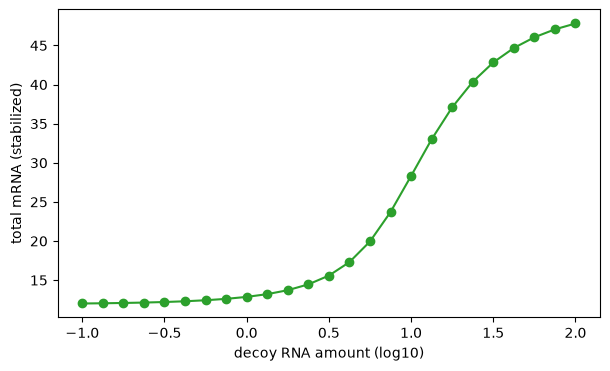

decoy 少: mRNA=12.0 → decoy 多: mRNA=47.8（デコイが mRNA を安定化）


In [4]:
Hd,Md,MdH,Dd,DdH = (Species(x) for x in ['H','m','mH','d','dH'])
def R2(a,b,k): return ReactionRule(a,b,k)
def decoy_steady(d0, h_tot=10.0, k_rnase=1.0):
    mdl=NetworkModel()
    for r in [R2([],[Md],5.0), R2([Md],[],0.1),                      # mRNA 転写/基礎分解
              R2([Md,Hd],[MdH],0.1), R2([MdH],[Md,Hd],0.05),         # distal 結合
              R2([MdH],[Hd],k_rnase),                                # RNase E 分解(Hfq放出)
              R2([Dd,Hd],[DdH],0.1), R2([DdH],[Dd,Hd],0.05)]:        # デコイが Hfq を奪う
        mdl.add_reaction_rule(r)
    names=['m','mH','d','dH','H']
    v=dict(zip(names, run_simulation(300.,y0={'H':h_tot,'d':d0},model=mdl,solver='ode',ndiv=1,species_list=names).as_array()[-1][1:]))
    return v['m']+v['mH']   # 総 mRNA
d_grid=np.logspace(-1,2,25); mm=[decoy_steady(d) for d in d_grid]
fig,ax=plt.subplots(figsize=(7,4)); ax.plot(np.log10(d_grid),mm,'o-',color='C2')
ax.set_xlabel('decoy RNA amount (log10)'); ax.set_ylabel('total mRNA (stabilized)'); plt.show()
print(f'decoy 少: mRNA={mm[0]:.1f} → decoy 多: mRNA={mm[-1]:.1f}（デコイが mRNA を安定化）')

**答**: デコイ RNA を増やすと Hfq を奪い、Hfq-distal-mRNA 複合体（RNase E を呼ぶ状態）が減るので、**mRNA が分解を免れて安定化**（総 mRNA が上昇）。sRNA 非依存の Hfq-RNase E 経路が、強い distal 結合 RNA によって「デコイ」される、という論文の主張を最小モデルで再現。

## Q4.（考察）bio-a: 能動交換は rim / C 末端テールに依存

**答（考察）**: 能動交換の速さ `k_ex` は Hfq の rim と C 末端テール（RNA 置換・排出を担う）に依存する。bio-e の 01_features が示すとおり、**γ-proteobacteria はテール長・rim Arg patch が保存、Firmicutes は両方欠落/短縮**。よって γ-proteo は `k_ex` 大＝分オーダーの速い応答、Firmicutes は `k_ex` 小＝応答が鈍い、と予測できる。これは bio-e 02_response_speed の中心テーマ。